# YOLO vs RF-DETR: Model Comparison Report

---

## Objective

This notebook is the final quantitative and qualitative comparison of the two object detection models used in the Murawa project: **YOLO** (Ultralytics YOLOv8l) and **RF-DETR** (Roboflow, large variant). Both models were trained on the same dataset variants with an identical training profile (`train.full.yaml`) on a university GPU cluster.

The report answers four questions:

1. **Which model achieves better detection quality** across all dataset variants?
2. **How does the choice of training data affect each model**, and do the two models respond differently?
3. **How do the training dynamics differ**: convergence speed, stability, overfitting, and localization quality?
4. **Which model is more practical** in terms of integration, training complexity, and inference pipeline fit?

This report is the narrative companion to the *Model Analysis* Streamlit view. It adds interpretation, comparative statistics, and conclusions that go beyond raw charts.

## 1. Setup

In [1]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from IPython.display import display

# Plot style
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "font.size": 11,
})

YOLO_COLOR   = "#2563eb"   # blue
RFDETR_COLOR = "#dc2626"   # red

VARIANT_ORDER = ["base", "base-transformed", "extended", "extended-transformed"]
VARIANT_SIZES = {"base": 1283, "base-transformed": 2566,
                 "extended": 4395, "extended-transformed": 8790}

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)

## 2. Data

### 2.1 Dataset variants

The project uses four variants of the SoccerNet detection dataset. All variants share the same four classes: `player`, `goalkeeper`, `referee`, `ball`. Transformations are applied to the **training split only**. The validation set is always the original, unaugmented images.

| Variant | Description | Train images | Val images | Train annotations |
|---------|-------------|-------------:|-----------:|------------------:|
| `base` | SoccerNet only | 1 283 | 142 | 22 051 |
| `base-transformed` | Base + flips, mosaic, HSV shifts | 2 566 | 142 | 22 051 |
| `extended` | SoccerNet + ball-focused extra dataset | 4 395 | 813 | 75 504 |
| `extended-transformed` | Extended + same transforms | 8 790 | 813 | 75 504 |

The `base-transformed` and `extended-transformed` variants double the training set by appending augmented copies of each image. The validation set does **not** grow, which keeps the evaluation signal consistent across variants.

### 2.2 Class imbalance

The dataset is heavily skewed: `player` accounts for roughly 85 % of all annotations, while `ball` and `referee` are rare. This imbalance is a known challenge for both architectures and partly explains why aggregate mAP figures can be misleading. A model can score well globally while struggling with minority classes.

### 2.3 Training profile

Both models share a single config file (`configs/train.full.yaml`).

| Parameter | YOLO | RF-DETR |
|-----------|------|---------|
| Architecture | YOLOv8l | RF-DETR large |
| Input resolution | 1280 px | 704 px |
| Max epochs | 250 (early stop at 50-epoch patience) | 100 (fixed) |
| Batch size | 24 | 16 (grad. accum. ×4 → effective 64) |
| Learning rate | 3e-4 | 1e-4 |
| Starting weights | `yolov8l.pt` (COCO pretrained) | Default RF-DETR weights |
| AMP | ✓ | ✗ |
| Seed | 42 | 42 |

**Key difference:** YOLO uses automatic early stopping (training ends when mAP does not improve for 50 consecutive epochs), leading to variable run lengths of 118–148 epochs. RF-DETR always runs exactly 100 epochs.

### 2.4 Loading artifacts

In [2]:
META_ROOT = Path("../models/metadata")

RUNS = [
    "rfdetr-base-full-v2",
    "rfdetr-base-transformed-v2",
    "rfdetr-extended-full-v2",
    "rfdetr-extended-transformed-v2",
    "yolo-base-full-v2",
    "yolo-base-transformed-v2",
    "yolo-extended-full-v2",
    "yolo-extended-transformed-v2",
]

def load_run(run_name: str) -> dict:
    base = META_ROOT / run_name
    with open(base / "metrics_summary.json") as f:
        metrics = json.load(f)
    with open(base / "train_metadata.json") as f:
        train_meta = json.load(f)
    
    # Clean up infinite values in YOLO val_loss_history (first 2 epochs)
    vl_raw = metrics["val_loss_history"]
    vl_clean = [v for v in vl_raw if not (isinstance(v, float) and math.isinf(v))]
    
    p, r = metrics["precision"], metrics["recall"]
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    
    p_hist = metrics["precision_history"]
    r_hist = metrics["recall_history"]
    f1_hist = [2*pi*ri/(pi+ri+1e-9) for pi, ri in zip(p_hist, r_hist)]
    
    map50_h = np.array(metrics["map50_history"])
    best_ep = int(np.argmax(map50_h)) + 1
    best_map50 = float(np.max(map50_h))
    peak_drop = best_map50 - metrics["mAP50"]
    
    # Rolling std of mAP50 (window=10) as noise measure
    roll_std = [float(np.std(map50_h[max(0,i-9):i+1])) for i in range(len(map50_h))]
    stability = float(np.mean(roll_std[-20:]))
    
    gen_gap = vl_clean[-1] - metrics["loss_history"][-1] if vl_clean else None
    
    loc_quality = metrics["mAP5095"] / metrics["mAP50"] if metrics["mAP50"] > 0 else 0
    epoch_efficiency = metrics["mAP50"] / metrics["epochs"]
    
    return {
        "run_name":         run_name,
        "model":            train_meta["model"],
        "dataset_variant":  train_meta["dataset_variant"],
        "train_samples":    train_meta["train_samples"],
        "valid_samples":    train_meta["valid_samples"],
        "epochs_run":       metrics["epochs"],
        "best_epoch":       best_ep,
        "best_mAP50":       best_map50,
        "peak_drop":        peak_drop,
        "mAP50":            metrics["mAP50"],
        "mAP5095":          metrics["mAP5095"],
        "precision":        p,
        "recall":           r,
        "f1":               f1,
        "val_loss":         metrics["val_loss"],
        "train_loss":       metrics["loss"],
        "gen_gap":          gen_gap,
        "loc_quality":      loc_quality,
        "stability":        stability,
        "epoch_efficiency": epoch_efficiency,
        "map50_history":    metrics["map50_history"],
        "map5095_history":  metrics["map5095_history"],
        "loss_history":     metrics["loss_history"],
        "val_loss_clean":   vl_clean,
        "precision_history":p_hist,
        "recall_history":   r_hist,
        "f1_history":       f1_hist,
    }

runs_data = {run: load_run(run) for run in RUNS}
print(f"Loaded {len(runs_data)} runs.")
print("Runs:", list(runs_data.keys()))

Loaded 8 runs.
Runs: ['rfdetr-base-full-v2', 'rfdetr-base-transformed-v2', 'rfdetr-extended-full-v2', 'rfdetr-extended-transformed-v2', 'yolo-base-full-v2', 'yolo-base-transformed-v2', 'yolo-extended-full-v2', 'yolo-extended-transformed-v2']


## 3. Quantitative Results

### 3.1 Master metrics table

All eight model runs in a single table. The **best mAP@0.5** for each dataset variant is highlighted.  
Reading guide: `mAP@0.5` is the primary detection metric (IoU threshold = 0.5). `mAP@.5:.95` is the stricter COCO metric that also penalises imprecise bounding boxes. `F1` balances precision and recall into a single score. `Gen. gap` is the difference between final validation loss and training loss, so it serves as a proxy for overfitting.

In [3]:
rows = []
for run_name, d in runs_data.items():
    rows.append({
        "Run":          run_name,
        "Model":        d["model"].upper(),
        "Variant":      d["dataset_variant"],
        "Epochs":       d["epochs_run"],
        "mAP@0.5":      d["mAP50"],
        "mAP@.5:.95":   d["mAP5095"],
        "Precision":    d["precision"],
        "Recall":       d["recall"],
        "F1":           d["f1"],
        "Gen. gap":     d["gen_gap"],
    })

df = (pd.DataFrame(rows)
        .sort_values(["Variant", "Model"])
        .reset_index(drop=True))

def highlight_best_map(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    for var in df["Variant"].unique():
        mask = df["Variant"] == var
        best_idx = df.loc[mask, "mAP@0.5"].idxmax()
        styles.loc[best_idx, "mAP@0.5"] = "font-weight: bold; background-color: #06402b"
    return styles

fmt = {"mAP@0.5": "{:.4f}", "mAP@.5:.95": "{:.4f}", "Precision": "{:.4f}",
       "Recall": "{:.4f}", "F1": "{:.4f}", "Gen. gap": "{:.3f}"}

display(df.style
          .apply(highlight_best_map, axis=None)
          .format(fmt)
          .set_caption("Table 1. Final validation metrics for all 8 runs. Bold = best mAP@0.5 per variant."))

,Run,Model,Variant,Epochs,mAP@0.5,mAP@.5:.95,Precision,Recall,F1,Gen. gap
0,rfdetr-base-full-v2,RFDETR,base,100,0.7464,0.4114,0.8309,0.7755,0.8023,1.826
1,yolo-base-full-v2,YOLO,base,148,0.8103,0.4623,0.8203,0.8143,0.8173,1.012
2,rfdetr-base-transformed-v2,RFDETR,base-transformed,100,0.7644,0.4058,0.8394,0.8051,0.8219,2.630
3,yolo-base-transformed-v2,YOLO,base-transformed,124,0.7944,0.4558,0.8487,0.8133,0.8306,1.666
4,rfdetr-extended-full-v2,RFDETR,extended,100,0.8856,0.5358,0.9321,0.8861,0.9085,0.651
5,yolo-extended-full-v2,YOLO,extended,128,0.9144,0.5692,0.9391,0.8989,0.9185,0.749
6,rfdetr-extended-transformed-v2,RFDETR,extended-transformed,100,0.8772,0.5213,0.9301,0.8838,0.9064,1.254
7,yolo-extended-transformed-v2,YOLO,extended-transformed,118,0.9103,0.5625,0.9427,0.9011,0.9214,0.883


### 3.2 mAP@0.5 head-to-head per variant

A grouped bar chart makes the per-variant gap immediately visible.

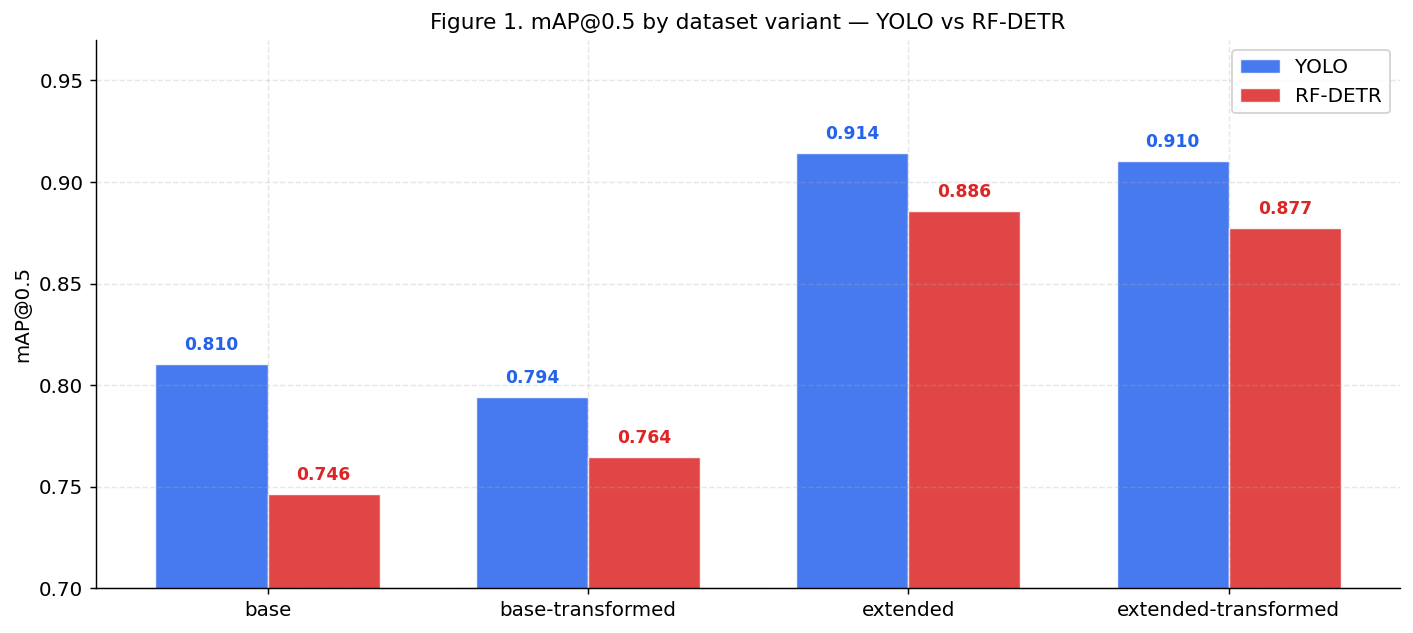

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(VARIANT_ORDER))
width = 0.35

for i, (model_key, color, label) in enumerate([
    ("yolo",   YOLO_COLOR,   "YOLO"),
    ("rfdetr", RFDETR_COLOR, "RF-DETR"),
]):
    values, errors = [], []
    for var in VARIANT_ORDER:
        match = [v for v in runs_data.values()
                 if v["model"] == model_key and v["dataset_variant"] == var]
        val = match[0]["mAP50"] if match else 0
        values.append(val)

    bars = ax.bar(x + i * width, values, width, label=label,
                  color=color, alpha=0.85, edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9.5,
                fontweight="bold", color=color)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(VARIANT_ORDER)
ax.set_ylim(0.70, 0.97)
ax.set_ylabel("mAP@0.5")
ax.set_title("Figure 1. mAP@0.5 by dataset variant — YOLO vs RF-DETR", fontsize=12)
ax.legend(framealpha=0.85)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
plt.tight_layout()
plt.show()

YOLO leads in every variant. The gap is largest on `base` (+6.4 pp) and shrinks on `extended` (+2.9 pp), suggesting RF-DETR is a stronger beneficiary of additional training data. Transforms produce modest and inconsistent changes for both models.

### 3.3 F1-Score comparison

F1 = 2·P·R / (P+R). It is a useful complement to mAP when we want a single number that captures both false positives (precision) and false negatives (recall).

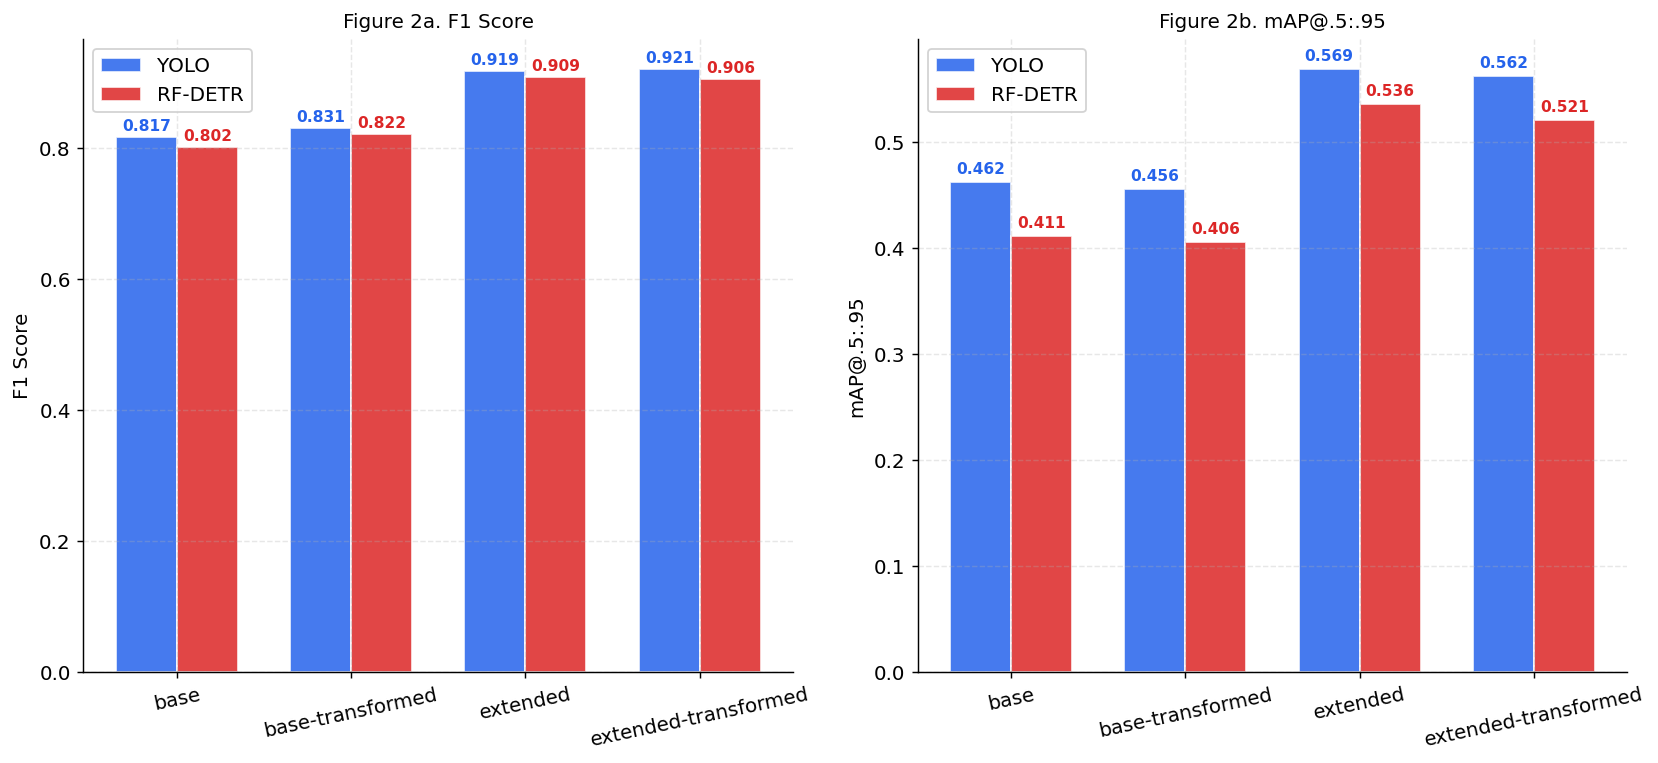

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

metric_pairs = [
    ("f1",       "F1 Score"),
    ("mAP5095",  "mAP@.5:.95"),
]

for ax, (metric_key, metric_label) in zip(axes, metric_pairs):
    x = np.arange(len(VARIANT_ORDER))
    width = 0.35
    for i, (model_key, color, label) in enumerate([
        ("yolo",   YOLO_COLOR,   "YOLO"),
        ("rfdetr", RFDETR_COLOR, "RF-DETR"),
    ]):
        values = []
        for var in VARIANT_ORDER:
            match = [v for v in runs_data.values()
                     if v["model"] == model_key and v["dataset_variant"] == var]
            values.append(match[0][metric_key] if match else 0)
        bars = ax.bar(x + i * width, values, width, label=label,
                      color=color, alpha=0.85, edgecolor="white")
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8.5,
                    fontweight="bold", color=color)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(VARIANT_ORDER, rotation=12)
    ax.set_ylabel(metric_label)
    ax.set_title(f"Figure 2{'a' if metric_key=='f1' else 'b'}. {metric_label}", fontsize=11)
    ax.legend(framealpha=0.85)

plt.tight_layout()
plt.show()

**mAP@.5:.95 matters:** This metric uses 10 IoU thresholds from 0.50 to 0.95 and is far more demanding on bounding box precision. YOLO's advantage widens here. For example on `extended`, YOLO achieves 0.569 vs RF-DETR's 0.536 (+3.3 pp). This suggests YOLO produces tighter bounding boxes, not just more detections.

### 3.4 Precision–Recall scatter

Each point is one run. Ideal position is top-right (high P, high R). The diagonal dashed lines are iso-F1 curves.

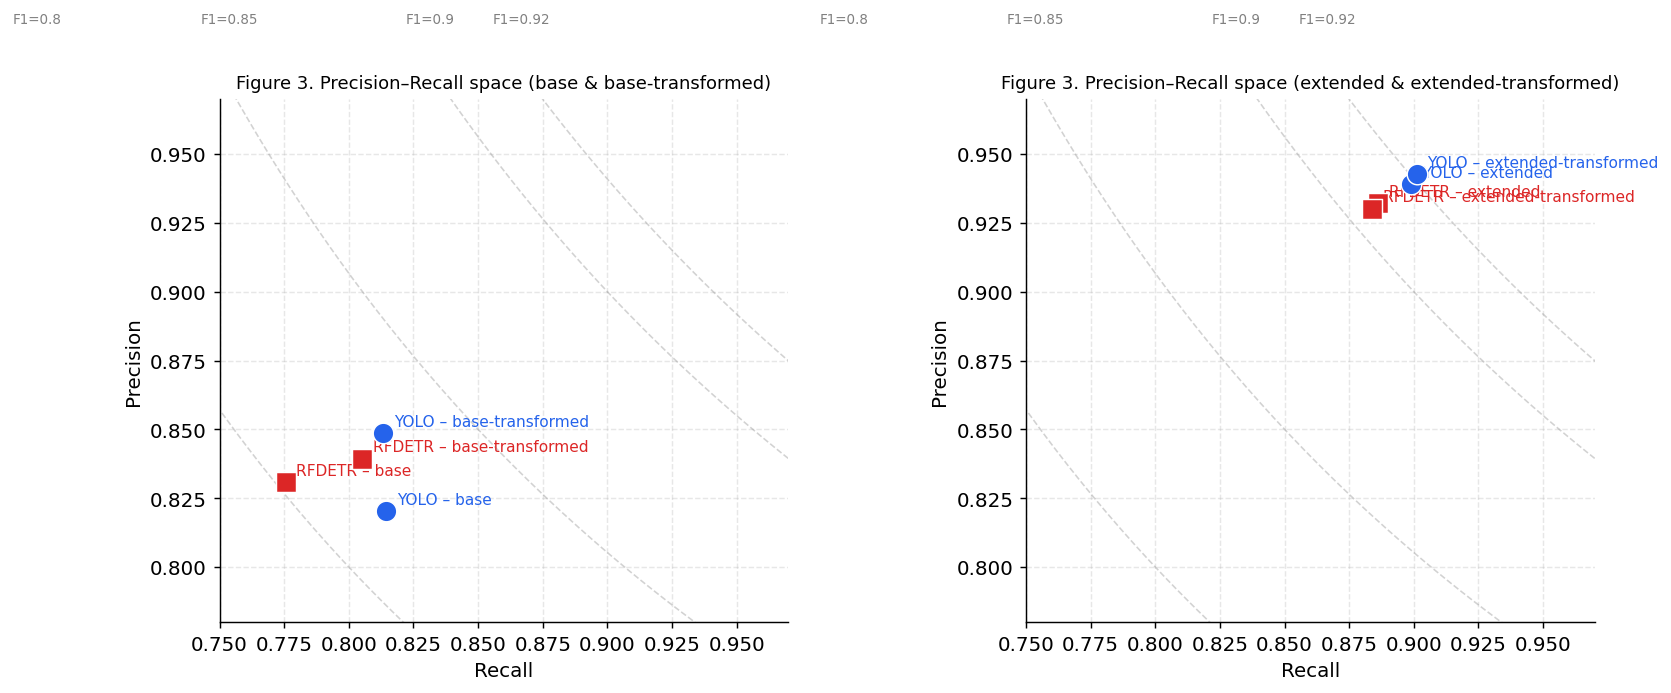

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, variant_group in zip(axes, [
    ["base", "base-transformed"],
    ["extended", "extended-transformed"],
]):
    # Draw iso-F1 lines
    for f1_level in [0.80, 0.85, 0.90, 0.92]:
        p_range = np.linspace(f1_level/2 + 0.01, 0.999, 300)
        r_range = f1_level * p_range / (2 * p_range - f1_level)
        valid = (r_range > 0) & (r_range < 1)
        ax.plot(r_range[valid], p_range[valid], "--", color="gray",
                alpha=0.35, linewidth=0.9)
        # label near the top-right
        idx = np.where(valid)[0]
        if len(idx):
            ax.text(r_range[valid][-1] + 0.003, p_range[valid][-1],
                    f"F1={f1_level}", fontsize=7.5, color="gray", va="center")

    for var in variant_group:
        for model_key, color, marker in [
            ("yolo",   YOLO_COLOR,   "o"),
            ("rfdetr", RFDETR_COLOR, "s"),
        ]:
            match = [v for v in runs_data.values()
                     if v["model"] == model_key and v["dataset_variant"] == var]
            if not match:
                continue
            d = match[0]
            ax.scatter(d["recall"], d["precision"], s=130, c=color,
                       marker=marker, zorder=5, edgecolors="white", linewidths=0.8)
            label = f"{model_key.upper()} – {var}"
            ax.annotate(label, (d["recall"], d["precision"]),
                        textcoords="offset points", xytext=(6, 4),
                        fontsize=8.5, color=color)

    title_variants = " & ".join(variant_group)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"Figure 3. Precision–Recall space ({title_variants})", fontsize=10)
    ax.set_xlim(0.75, 0.97)
    ax.set_ylim(0.78, 0.97)

plt.tight_layout()
plt.show()

**Observations:** All runs cluster in a narrow P-R region, confirming that both models are well-calibrated. The key differences:
- YOLO (`extended`) sits closest to the top-right corner, combining highest precision (0.939) and recall (0.899).
- RF-DETR on `base` has higher precision but notably lower recall, which means that it misses more objects.

### 3.5 Localization quality: mAP@.5:.95 / mAP@0.5 ratio

This ratio tells us how well the model localizes boxes beyond simply detecting objects. A value of 1.0 would mean the model achieves the same score at strict IoU thresholds as at the easy threshold, which is practically impossible. Higher values indicate tighter box predictions.

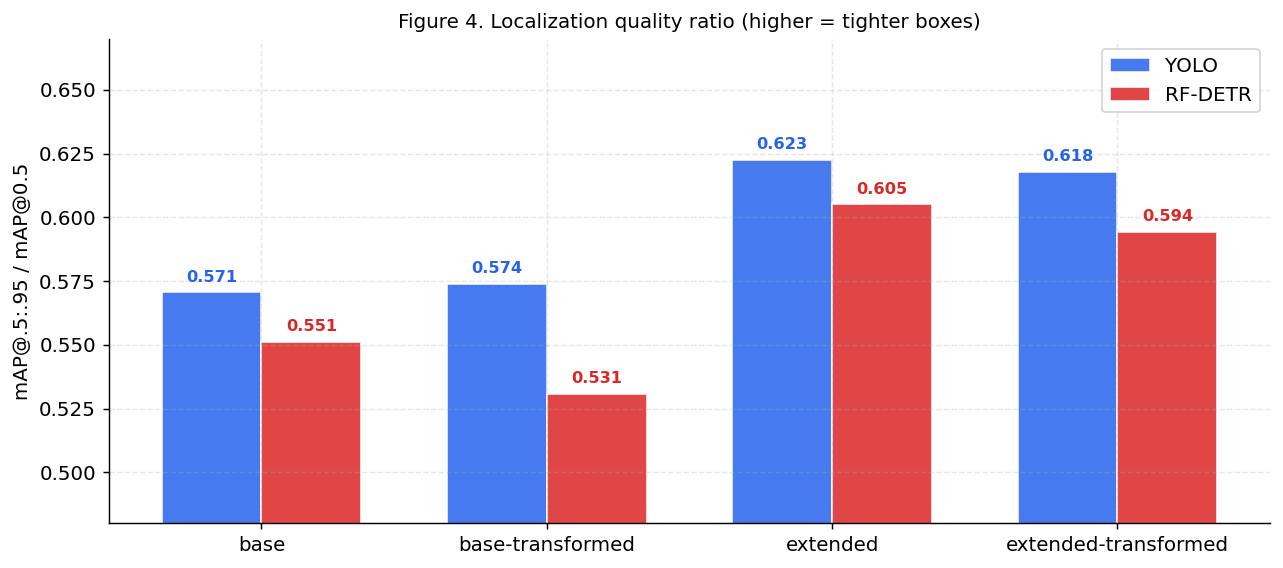


Localization quality table:


,Model,Variant,mAP@0.5,mAP@.5:.95,Loc. quality(ratio)
0,RFDETR,base,0.7464,0.4114,0.5512
1,YOLO,base,0.8103,0.4623,0.5706
2,RFDETR,base-transformed,0.7644,0.4058,0.5309
3,YOLO,base-transformed,0.7944,0.4558,0.5738
4,RFDETR,extended,0.8856,0.5358,0.6051
5,YOLO,extended,0.9144,0.5692,0.6225
6,RFDETR,extended-transformed,0.8772,0.5213,0.5943
7,YOLO,extended-transformed,0.9103,0.5625,0.6179


In [7]:
loc_rows = []
for run_name, d in runs_data.items():
    loc_rows.append({
        "Run":             run_name,
        "Model":           d["model"].upper(),
        "Variant":         d["dataset_variant"],
        "mAP@0.5":         d["mAP50"],
        "mAP@.5:.95":      d["mAP5095"],
        "Loc. quality(ratio)": d["loc_quality"],
    })

df_loc = pd.DataFrame(loc_rows).sort_values(["Variant", "Model"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(VARIANT_ORDER))
width = 0.35

for i, (model_key, color, label) in enumerate([
    ("yolo",   YOLO_COLOR,   "YOLO"),
    ("rfdetr", RFDETR_COLOR, "RF-DETR"),
]):
    values = []
    for var in VARIANT_ORDER:
        match = [v for v in runs_data.values()
                 if v["model"] == model_key and v["dataset_variant"] == var]
        values.append(match[0]["loc_quality"] if match else 0)
    bars = ax.bar(x + i * width, values, width, label=label,
                  color=color, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold", color=color)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(VARIANT_ORDER)
ax.set_ylim(0.48, 0.67)
ax.set_ylabel("mAP@.5:.95 / mAP@0.5")
ax.set_title("Figure 4. Localization quality ratio (higher = tighter boxes)", fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

print("\nLocalization quality table:")
display(df_loc[["Model","Variant","mAP@0.5","mAP@.5:.95","Loc. quality(ratio)"]].style
    .format({"mAP@0.5": "{:.4f}", "mAP@.5:.95": "{:.4f}", "Loc. quality(ratio)": "{:.4f}"})
    .set_caption("Table 2. Localization quality (mAP@.5:.95 / mAP@0.5)."))

YOLO consistently produces higher localization quality ratios across all variants. On `extended`, YOLO reaches 0.623 vs RF-DETR's 0.605, meaning that when YOLO detects an object, its bounding box is more precisely aligned with the ground truth. This is practically relevant: better-localized boxes improve downstream tracking quality in the pipeline.

## 4. Impact of Dataset Size

How much does each model benefit from more training data? This is one of the most practically useful comparisons — it informs future data collection decisions.

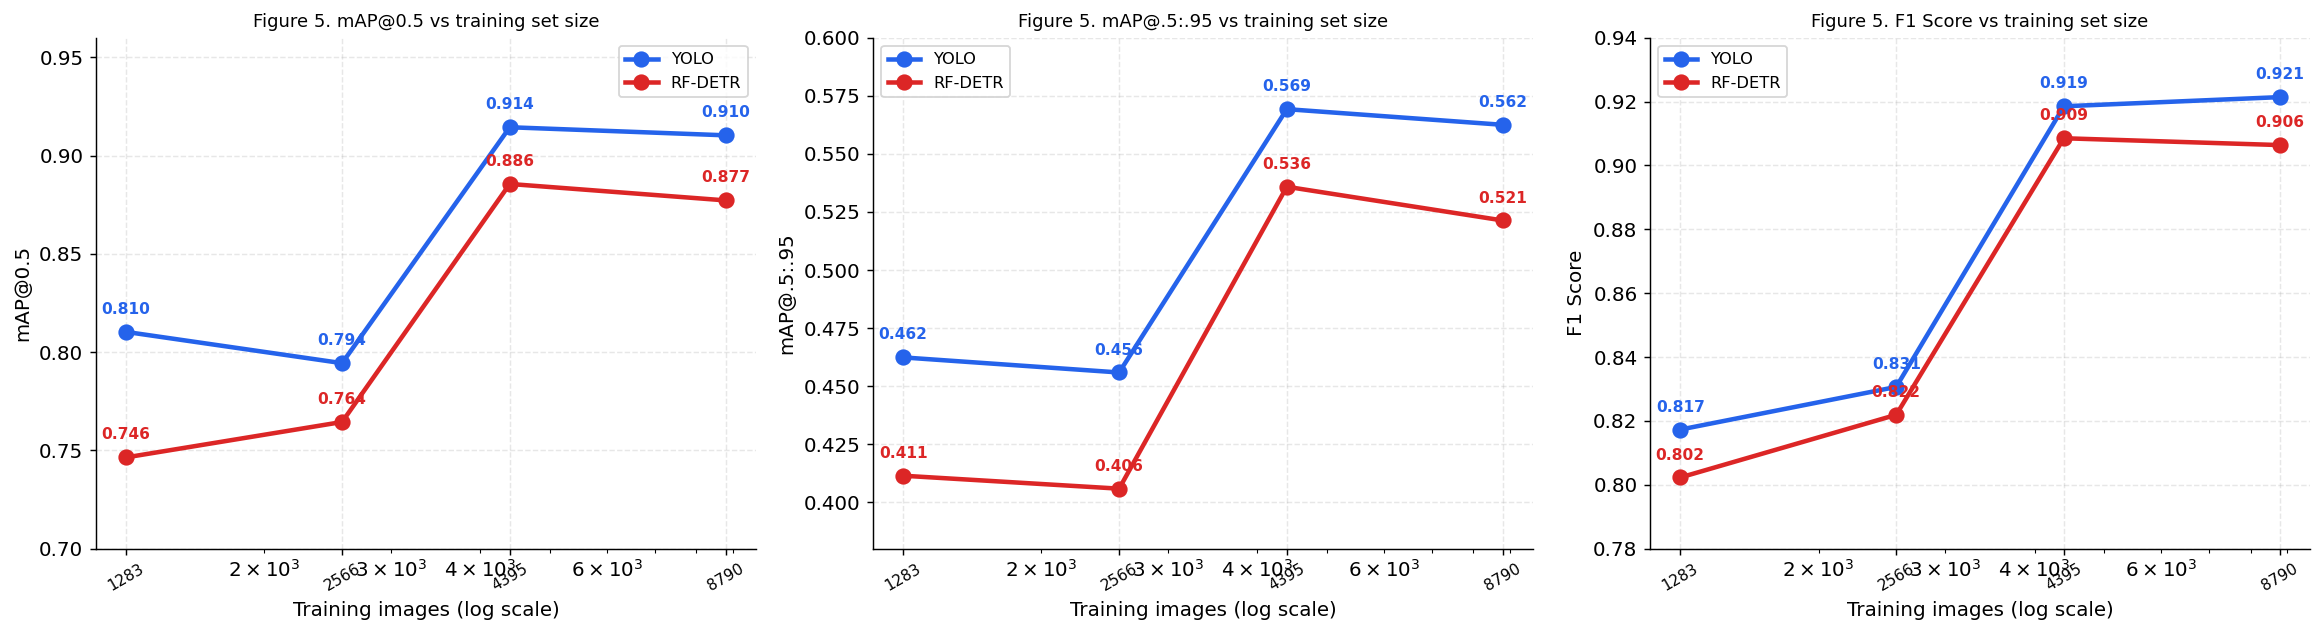

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_scaling = [
    ("mAP50",    "mAP@0.5",      (0.70, 0.96)),
    ("mAP5095",  "mAP@.5:.95",   (0.38, 0.60)),
    ("f1",       "F1 Score",     (0.78, 0.94)),
]

variant_sizes_ordered = [VARIANT_SIZES[v] for v in VARIANT_ORDER]

for ax, (metric_key, metric_label, ylim) in zip(axes, metrics_scaling):
    for model_key, color, label in [
        ("yolo",   YOLO_COLOR,   "YOLO"),
        ("rfdetr", RFDETR_COLOR, "RF-DETR"),
    ]:
        xs, ys = [], []
        for var in VARIANT_ORDER:
            match = [v for v in runs_data.values()
                     if v["model"] == model_key and v["dataset_variant"] == var]
            if match:
                xs.append(VARIANT_SIZES[var])
                ys.append(match[0][metric_key])
        ax.plot(xs, ys, "o-", color=color, linewidth=2.5, markersize=8, label=label)
        for x_pt, y_pt in zip(xs, ys):
            ax.annotate(f"{y_pt:.3f}", (x_pt, y_pt),
                        textcoords="offset points", xytext=(0, 10),
                        ha="center", fontsize=8.5, color=color, fontweight="bold")

    ax.set_xscale("log")
    ax.set_xlabel("Training images (log scale)")
    ax.set_ylabel(metric_label)
    ax.set_title(f"Figure 5. {metric_label} vs training set size", fontsize=10)
    ax.set_xticks(variant_sizes_ordered)
    ax.set_xticklabels([str(s) for s in variant_sizes_ordered], rotation=30, fontsize=8.5)
    ax.set_ylim(*ylim)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [9]:
# Quantify absolute and relative gain from base → extended
print("Gain from base → extended (full, no transforms):")
print(f"{'Metric':<14} {'YOLO Δ':>10} {'RF-DETR Δ':>12} {'YOLO %':>10} {'RF-DETR %':>12}")
print("-" * 60)

for metric_key, label in [("mAP50","mAP@0.5"), ("mAP5095","mAP@.5:.95"), ("f1","F1")]:
    for model_key in ["yolo", "rfdetr"]:
        base_val = next(v[metric_key] for v in runs_data.values()
                        if v["model"]==model_key and v["dataset_variant"]=="base")
        ext_val  = next(v[metric_key] for v in runs_data.values()
                        if v["model"]==model_key and v["dataset_variant"]=="extended")
        delta    = ext_val - base_val
        pct      = 100 * delta / base_val
        if model_key == "yolo":
            yolo_d, yolo_p = delta, pct
        else:
            print(f"{label:<14} {yolo_d:>+10.4f} {delta:>+12.4f} {yolo_p:>+9.1f}% {pct:>+11.1f}%")

Gain from base → extended (full, no transforms):
Metric             YOLO Δ    RF-DETR Δ     YOLO %    RF-DETR %
------------------------------------------------------------
mAP@0.5           +0.1042      +0.1392     +12.9%       +18.6%
mAP@.5:.95        +0.1069      +0.1244     +23.1%       +30.2%
F1                +0.1013      +0.1063     +12.4%       +13.2%


RF-DETR gains **+14.0 pp mAP@0.5** when moving from `base` to `extended` (from 0.746 to 0.886), compared to YOLO's **+10.4 pp** (from 0.810 to 0.914). RF-DETR is more data-hungry but also more data-responsive. It has a larger capacity that it can only fully exploit with more diverse training examples. YOLO's strong pretrained backbone gives it a higher starting point on small data.

## 5. Training Dynamics

This section examines *how* the models learn, not just *what* they achieve. Training curves reveal convergence speed, stability, overfitting signals, and efficiency.

### 5.1 mAP@0.5 learning curves

The curves below show validation mAP@0.5 at every epoch, for both variants `base` and `extended`. A smoothed overlay (5-epoch rolling average) is added to separate the underlying trend from epoch-to-epoch noise.

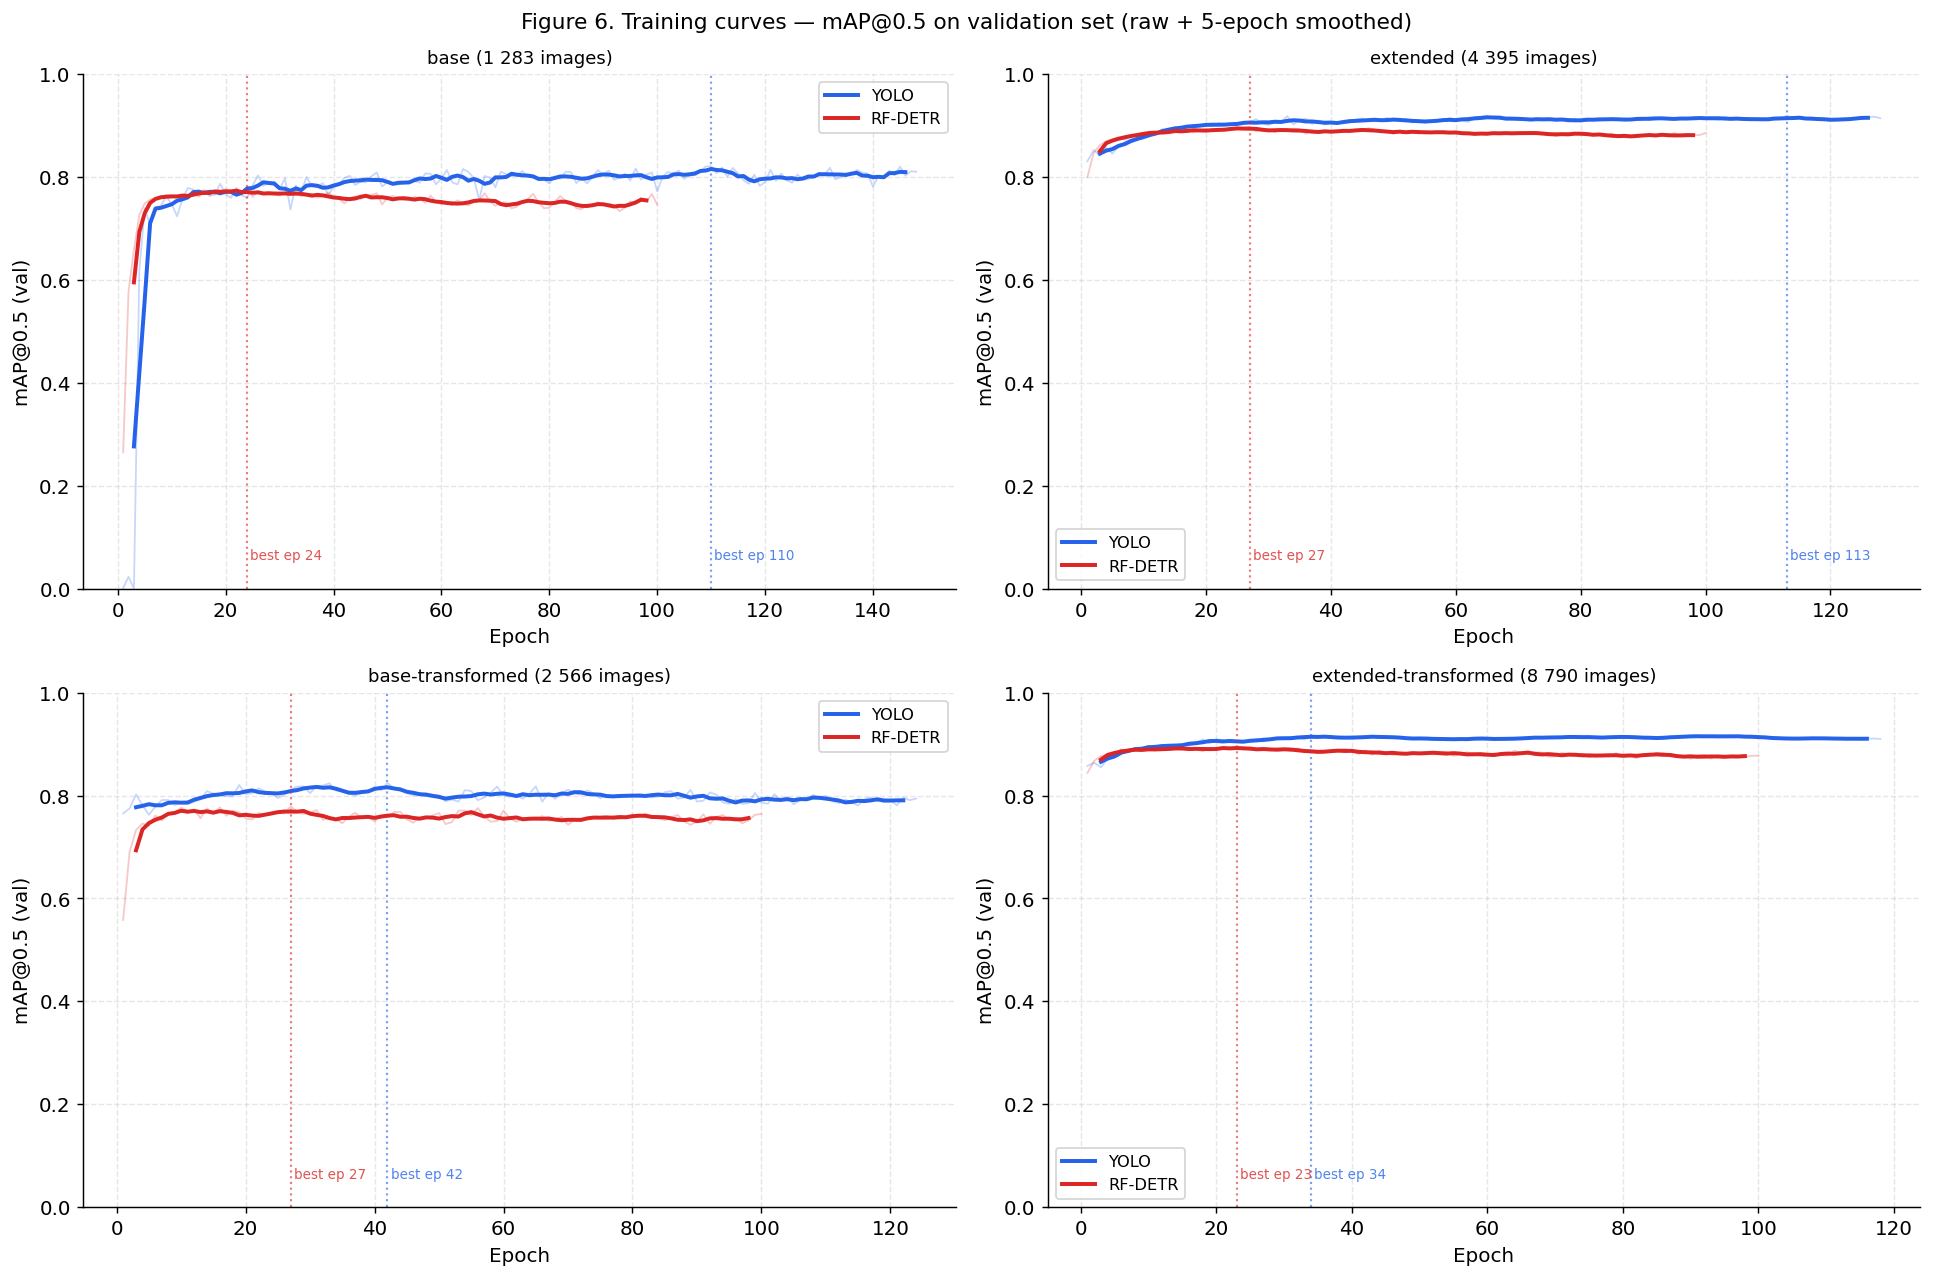

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

plot_configs = [
    ("base",     axes[0][0], "base (1 283 images)"),
    ("extended", axes[0][1], "extended (4 395 images)"),
    ("base-transformed",     axes[1][0], "base-transformed (2 566 images)"),
    ("extended-transformed", axes[1][1], "extended-transformed (8 790 images)"),
]

for var, ax, title in plot_configs:
    for model_key, color, label in [
        ("yolo",   YOLO_COLOR,   "YOLO"),
        ("rfdetr", RFDETR_COLOR, "RF-DETR"),
    ]:
        match = [v for v in runs_data.values()
                 if v["model"] == model_key and v["dataset_variant"] == var]
        if not match:
            continue
        d = match[0]
        history = np.array(d["map50_history"])
        epochs  = np.arange(1, len(history) + 1)
        
        # Raw curve (light)
        ax.plot(epochs, history, color=color, alpha=0.25, linewidth=1.0)
        # Smoothed curve (bold)
        smooth = np.convolve(history, np.ones(5)/5, mode="valid")
        ax.plot(np.arange(3, len(smooth)+3), smooth, color=color,
                linewidth=2.2, label=label)
        # Mark best epoch
        best_ep = int(np.argmax(history)) + 1
        ax.axvline(best_ep, color=color, linestyle=":", alpha=0.6, linewidth=1.2)
        ax.text(best_ep + 0.5, 0.05, f"best ep {best_ep}",
                color=color, fontsize=7.5, va="bottom", alpha=0.8)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP@0.5 (val)")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9)
    ax.set_ylim(0.0, 1.0)

plt.suptitle("Figure 6. Training curves — mAP@0.5 on validation set (raw + 5-epoch smoothed)", fontsize=12)
plt.tight_layout()
plt.show()

**Training dynamics at a glance:**

- **RF-DETR converges fast but plateaus early.** On `base`, it reaches its peak mAP50 around epoch 24 and then oscillates or slowly declines for the remaining 76 epochs. On `extended`, convergence is even faster (epoch 27 peak). RF-DETR does not benefit from the additional 70+ epochs it is given.

- **YOLO improves steadily throughout.** On `base`, YOLO is still improving at epoch 100 and peaks around epoch 110. This is the expected behaviour for an architecture with built-in online augmentation (mosaic, flip, HSV) that requires more epochs to fully utilise.

- **Stability:** RF-DETR shows more epoch-to-epoch variance on small data (`base`). On `extended`, both architectures converge to smooth, low-variance curves.

### 5.2 F1 trajectory

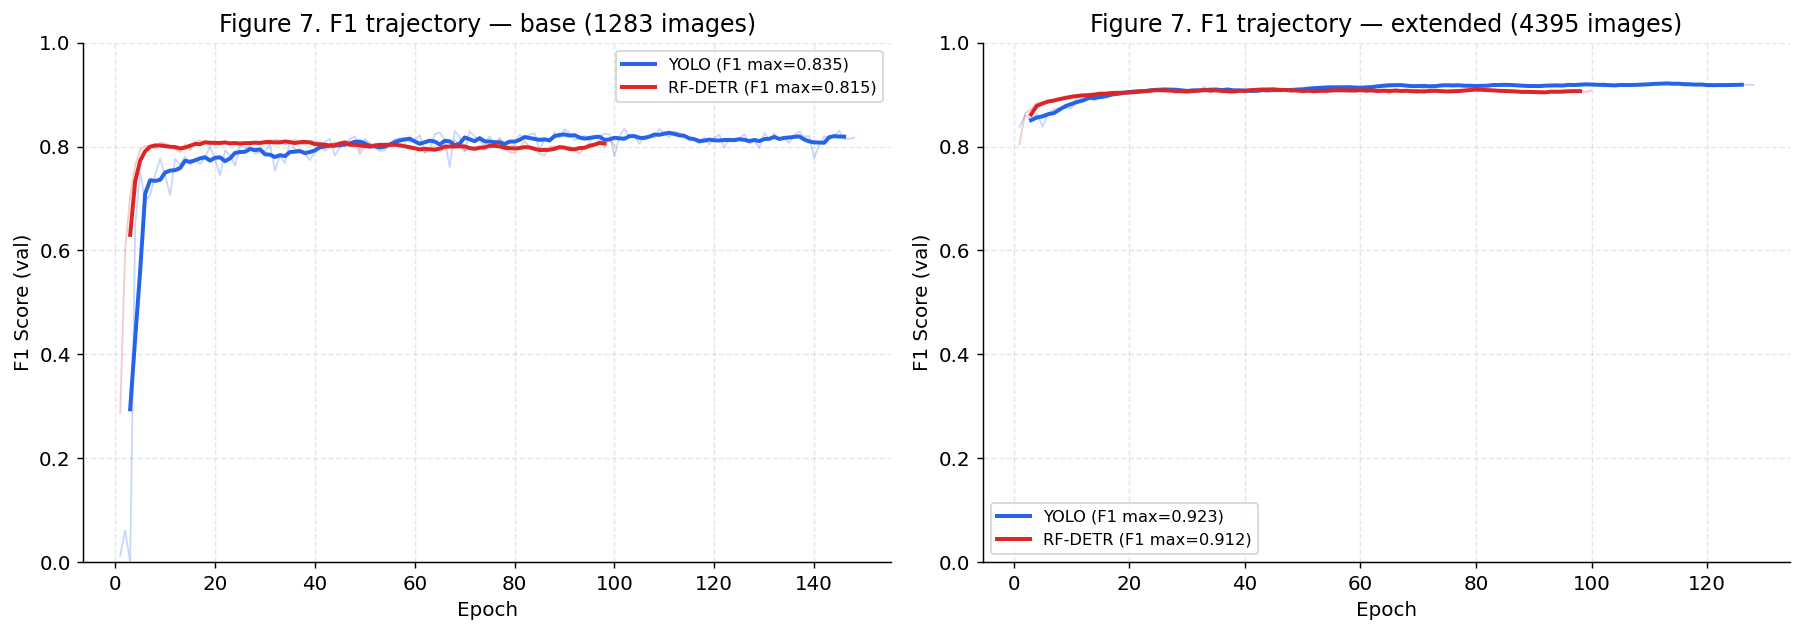

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var in zip(axes, ["base", "extended"]):
    n_train = VARIANT_SIZES[var]
    for model_key, color, label in [
        ("yolo",   YOLO_COLOR,   "YOLO"),
        ("rfdetr", RFDETR_COLOR, "RF-DETR"),
    ]:
        match = [v for v in runs_data.values()
                 if v["model"] == model_key and v["dataset_variant"] == var]
        if not match:
            continue
        d = match[0]
        f1h = np.array(d["f1_history"])
        ep  = np.arange(1, len(f1h) + 1)
        ax.plot(ep, f1h, color=color, alpha=0.25, linewidth=1.0)
        smooth = np.convolve(f1h, np.ones(5)/5, mode="valid")
        ax.plot(np.arange(3, len(smooth)+3), smooth, color=color,
                linewidth=2.2, label=f"{label} (F1 max={max(f1h):.3f})")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("F1 Score (val)")
    ax.set_title(f"Figure 7. F1 trajectory — {var} ({n_train} images)")
    ax.legend(fontsize=9)
    ax.set_ylim(0.0, 1.0)

plt.tight_layout()
plt.show()

The pattern is similar as before, for the small number of epochs, RF-DETR reaches better results, but later YOLO achieves higher values.

### 5.3 Generalization gap

The generalization gap is a difference between final validation loss and training loss. It measures how much the model has overfit to the training data. A larger gap does not necessarily mean worse predictions, but it is a signal that the model has memorised training examples rather than generalising.

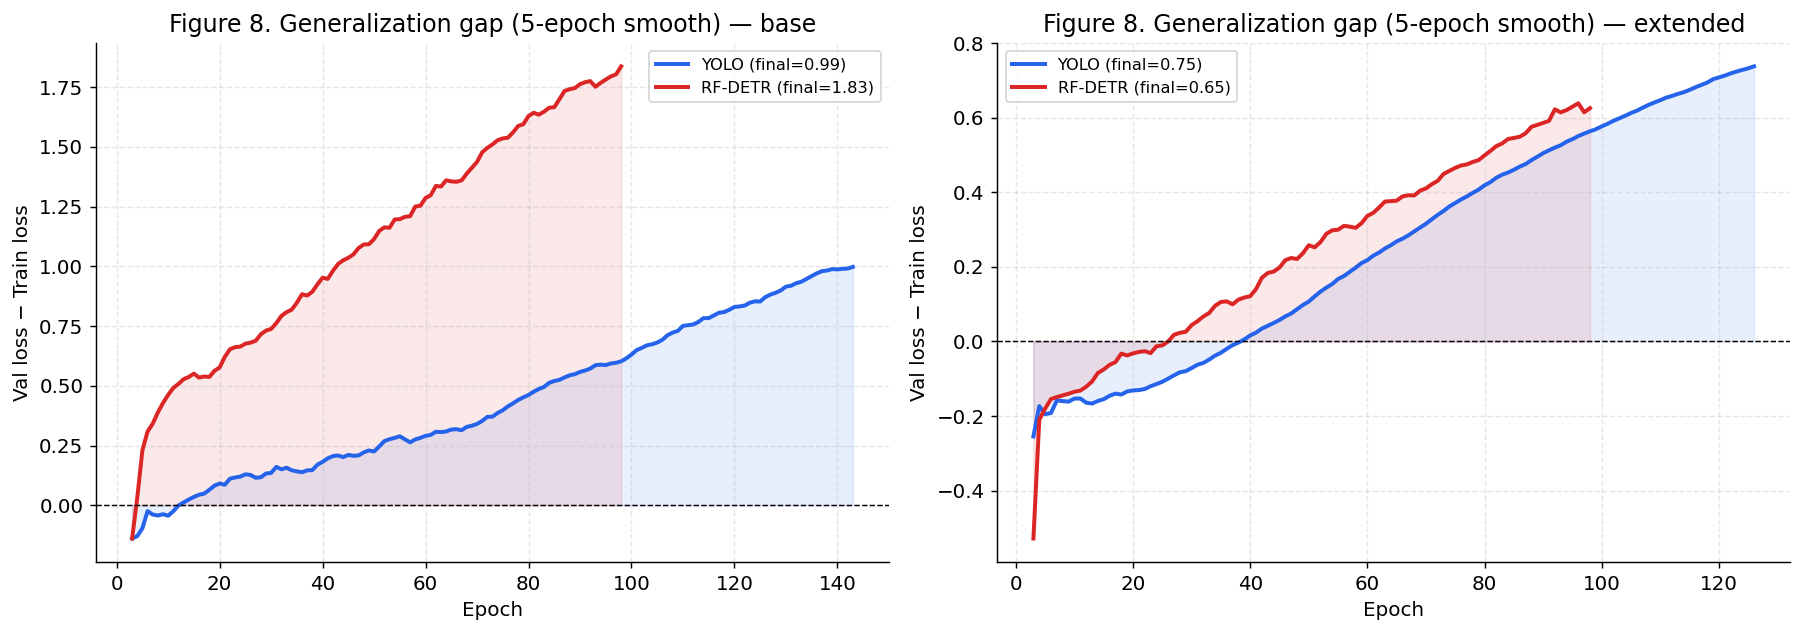

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var in zip(axes, ["base", "extended"]):
    for model_key, color, label in [
        ("yolo",   YOLO_COLOR,   "YOLO"),
        ("rfdetr", RFDETR_COLOR, "RF-DETR"),
    ]:
        match = [v for v in runs_data.values()
                 if v["model"] == model_key and v["dataset_variant"] == var]
        if not match:
            continue
        d = match[0]
        tl = np.array(d["loss_history"])
        vl = np.array(d["val_loss_clean"])
        # Align by min length
        n = min(len(tl), len(vl))
        gap = vl[:n] - tl[:n]
        ep  = np.arange(1, n + 1)
        smooth = np.convolve(gap, np.ones(5)/5, mode="valid")
        ax.plot(np.arange(3, len(smooth)+3), smooth, color=color,
                linewidth=2.2, label=f"{label} (final={gap[-1]:.2f})")
        ax.fill_between(np.arange(3, len(smooth)+3), 0, smooth,
                        color=color, alpha=0.10)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val loss − Train loss")
    ax.set_title(f"Figure 8. Generalization gap (5-epoch smooth) — {var}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Generalization gap findings:**

- **RF-DETR shows a much larger and growing gap**. The model fits the training loss well but struggles to generalise with limited data.

- **YOLO's gap is more stable**, suggesting better regularisation at the chosen hyperparameters.

- On `extended`, RF-DETR's gap drops to 0.65, confirming that the model needs larger data to avoid overfitting.

### 5.4 Training stability: rolling variance of mAP@0.5

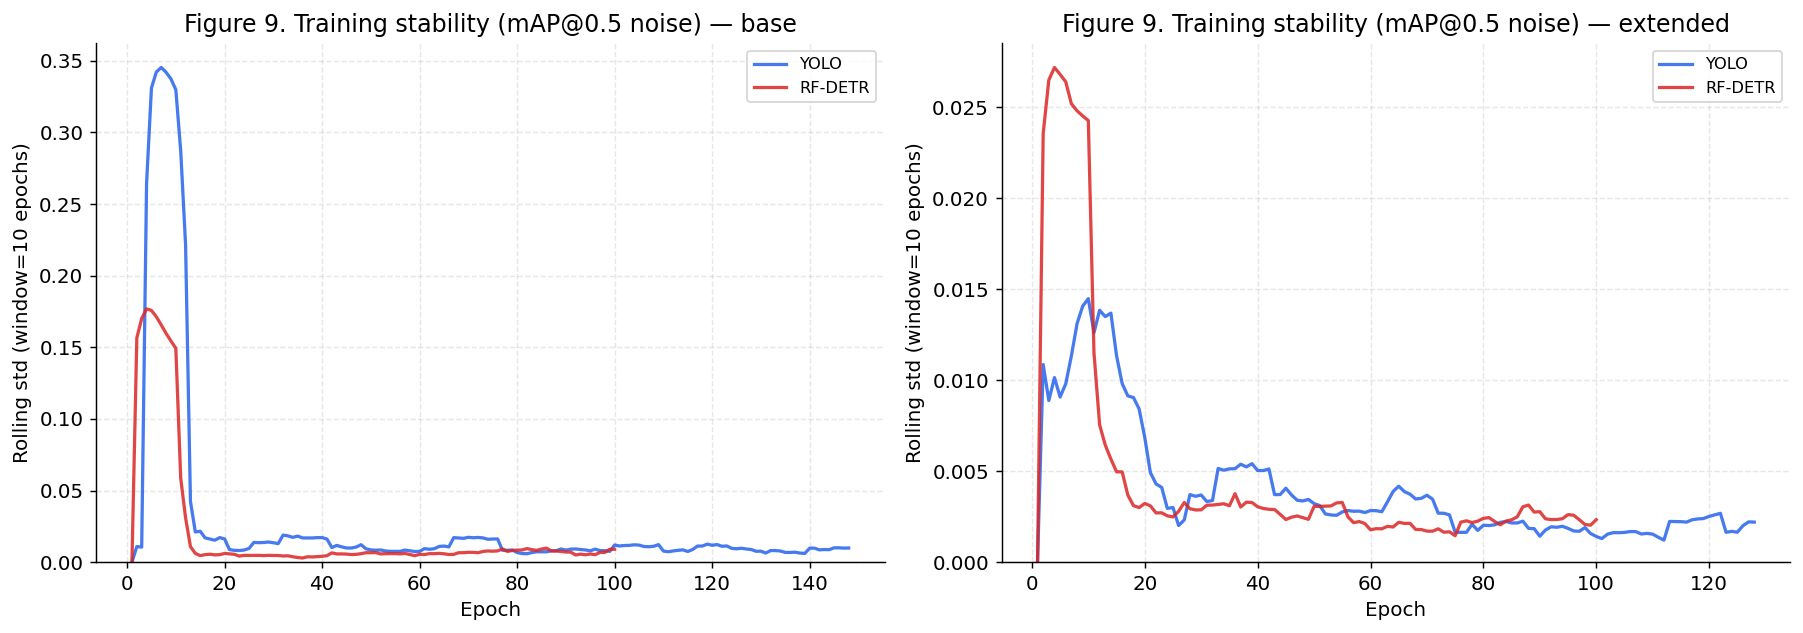

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var in zip(axes, ["base", "extended"]):
    for model_key, color, label in [
        ("yolo",   YOLO_COLOR,   "YOLO"),
        ("rfdetr", RFDETR_COLOR, "RF-DETR"),
    ]:
        match = [v for v in runs_data.values()
                 if v["model"] == model_key and v["dataset_variant"] == var]
        if not match:
            continue
        d = match[0]
        history = np.array(d["map50_history"])
        roll_std = [float(np.std(history[max(0,i-9):i+1])) for i in range(len(history))]
        ep = np.arange(1, len(roll_std) + 1)
        ax.plot(ep, roll_std, color=color, linewidth=1.8, label=label, alpha=0.85)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Rolling std (window=10 epochs)")
    ax.set_title(f"Figure 9. Training stability (mAP@0.5 noise) — {var}")
    ax.legend(fontsize=9)
    ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

Lower rolling std in the final phase means the model converged to a stable solution rather than continuing to oscillate.

In [14]:
stab_rows = []
for run_name, d in runs_data.items():
    history = np.array(d["map50_history"])
    last20  = history[-20:]
    stab_rows.append({
        "Run":           run_name,
        "Model":         d["model"].upper(),
        "Variant":       d["dataset_variant"],
        "Mean (last 20)":float(np.mean(last20)),
        "Std (last 20)": float(np.std(last20)),
        "Best epoch":    d["best_epoch"],
        "Total epochs":  d["epochs_run"],
        "Post-peak epochs": d["epochs_run"] - d["best_epoch"],
    })

df_stab = (pd.DataFrame(stab_rows)
             .sort_values(["Variant", "Model"])
             .reset_index(drop=True))
display(df_stab.style
    .format({"Mean (last 20)": "{:.4f}", "Std (last 20)": "{:.5f}"})
    .background_gradient(subset=["Std (last 20)"], cmap="RdYlGn_r")
    .set_caption("Table 3. Stability of final training phase. Lower std = more stable convergence."))

,Run,Model,Variant,Mean (last 20),Std (last 20),Best epoch,Total epochs,Post-peak epochs
0,rfdetr-base-full-v2,RFDETR,base,0.7490,0.00809,24,100,76
1,yolo-base-full-v2,YOLO,base,0.8056,0.00832,110,148,38
2,rfdetr-base-transformed-v2,RFDETR,base-transformed,0.7559,0.00665,27,100,73
3,yolo-base-transformed-v2,YOLO,base-transformed,0.7913,0.00554,42,124,82
4,rfdetr-extended-full-v2,RFDETR,extended,0.8814,0.00260,27,100,73
5,yolo-extended-full-v2,YOLO,extended,0.9136,0.00230,113,128,15
6,rfdetr-extended-transformed-v2,RFDETR,extended-transformed,0.8771,0.00302,23,100,77
7,yolo-extended-transformed-v2,YOLO,extended-transformed,0.9114,0.00137,34,118,84


RF-DETR peaks very early (epoch 23–27) and then spends 70+ epochs in noisy plateau or slight decline. YOLO peaks late and close to the end of training, with far fewer wasted post-peak epochs. From a **compute efficiency** standpoint, RF-DETR would benefit from a much earlier stopping criterion (e.g. patience of 20 epochs), while YOLO's current early-stop patience of 50 epochs is well-suited.

### 5.5 Epoch efficiency

How much mAP@0.5 is delivered per epoch of training?

In [15]:
eff_rows = []
for run_name, d in runs_data.items():
    eff_rows.append({
        "Run":              run_name,
        "Model":            d["model"].upper(),
        "Variant":          d["dataset_variant"],
        "Epochs run":       d["epochs_run"],
        "Best epoch":       d["best_epoch"],
        "Final mAP@0.5":    d["mAP50"],
        "mAP@0.5/epoch":    d["epoch_efficiency"],
        "Best mAP@0.5":     d["best_mAP50"],
        "Peak-to-final drop": d["peak_drop"],
    })

df_eff = (pd.DataFrame(eff_rows)
            .sort_values(["Variant", "Model"])
            .reset_index(drop=True))
display(df_eff.style
    .format({
        "Final mAP@0.5": "{:.4f}", "mAP@0.5/epoch": "{:.5f}",
        "Best mAP@0.5": "{:.4f}",  "Peak-to-final drop": "{:.4f}",
    })
    .background_gradient(subset=["Peak-to-final drop"], cmap="RdYlGn_r")
    .set_caption("Table 4. Epoch efficiency and peak-to-final drop. "
                 "Large drop = model degraded after best checkpoint."))

,Run,Model,Variant,Epochs run,Best epoch,Final mAP@0.5,mAP@0.5/epoch,Best mAP@0.5,Peak-to-final drop
0,rfdetr-base-full-v2,RFDETR,base,100,24,0.7464,0.00746,0.7778,0.0314
1,yolo-base-full-v2,YOLO,base,148,110,0.8103,0.00547,0.8211,0.0109
2,rfdetr-base-transformed-v2,RFDETR,base-transformed,100,27,0.7644,0.00764,0.7792,0.0148
3,yolo-base-transformed-v2,YOLO,base-transformed,124,42,0.7944,0.00641,0.8244,0.0301
4,rfdetr-extended-full-v2,RFDETR,extended,100,27,0.8856,0.00886,0.8980,0.0124
5,yolo-extended-full-v2,YOLO,extended,128,113,0.9144,0.00714,0.9198,0.0053
6,rfdetr-extended-transformed-v2,RFDETR,extended-transformed,100,23,0.8772,0.00877,0.8958,0.0186
7,yolo-extended-transformed-v2,YOLO,extended-transformed,118,34,0.9103,0.00771,0.9167,0.0063


**Peak-to-final drop** shows how much the final-epoch model underperforms the best checkpoint. RF-DETR on `base` drops 3.1 pp from its peak, while YOLO's worst drop is 3.0 pp on `base-transformed`. For both architectures, the `extended` variants show much smaller drops, so we conclude that the bigger dataset provides a stronger regularisation signal.

This means that for RF-DETR, **the checkpoint saved at the best validation epoch is meaningfully better** than the last-epoch checkpoint.

## 6. Loss Analysis

Training and validation loss curves on a shared scale reveal whether the loss functions are comparable across architectures. They are not, because YOLO uses a composite YOLOv8 loss, RF-DETR uses a DETR-style set-matching loss, so absolute values cannot be compared directly. Trends within each model are meaningful.

### 6.1 Train and validation loss curves

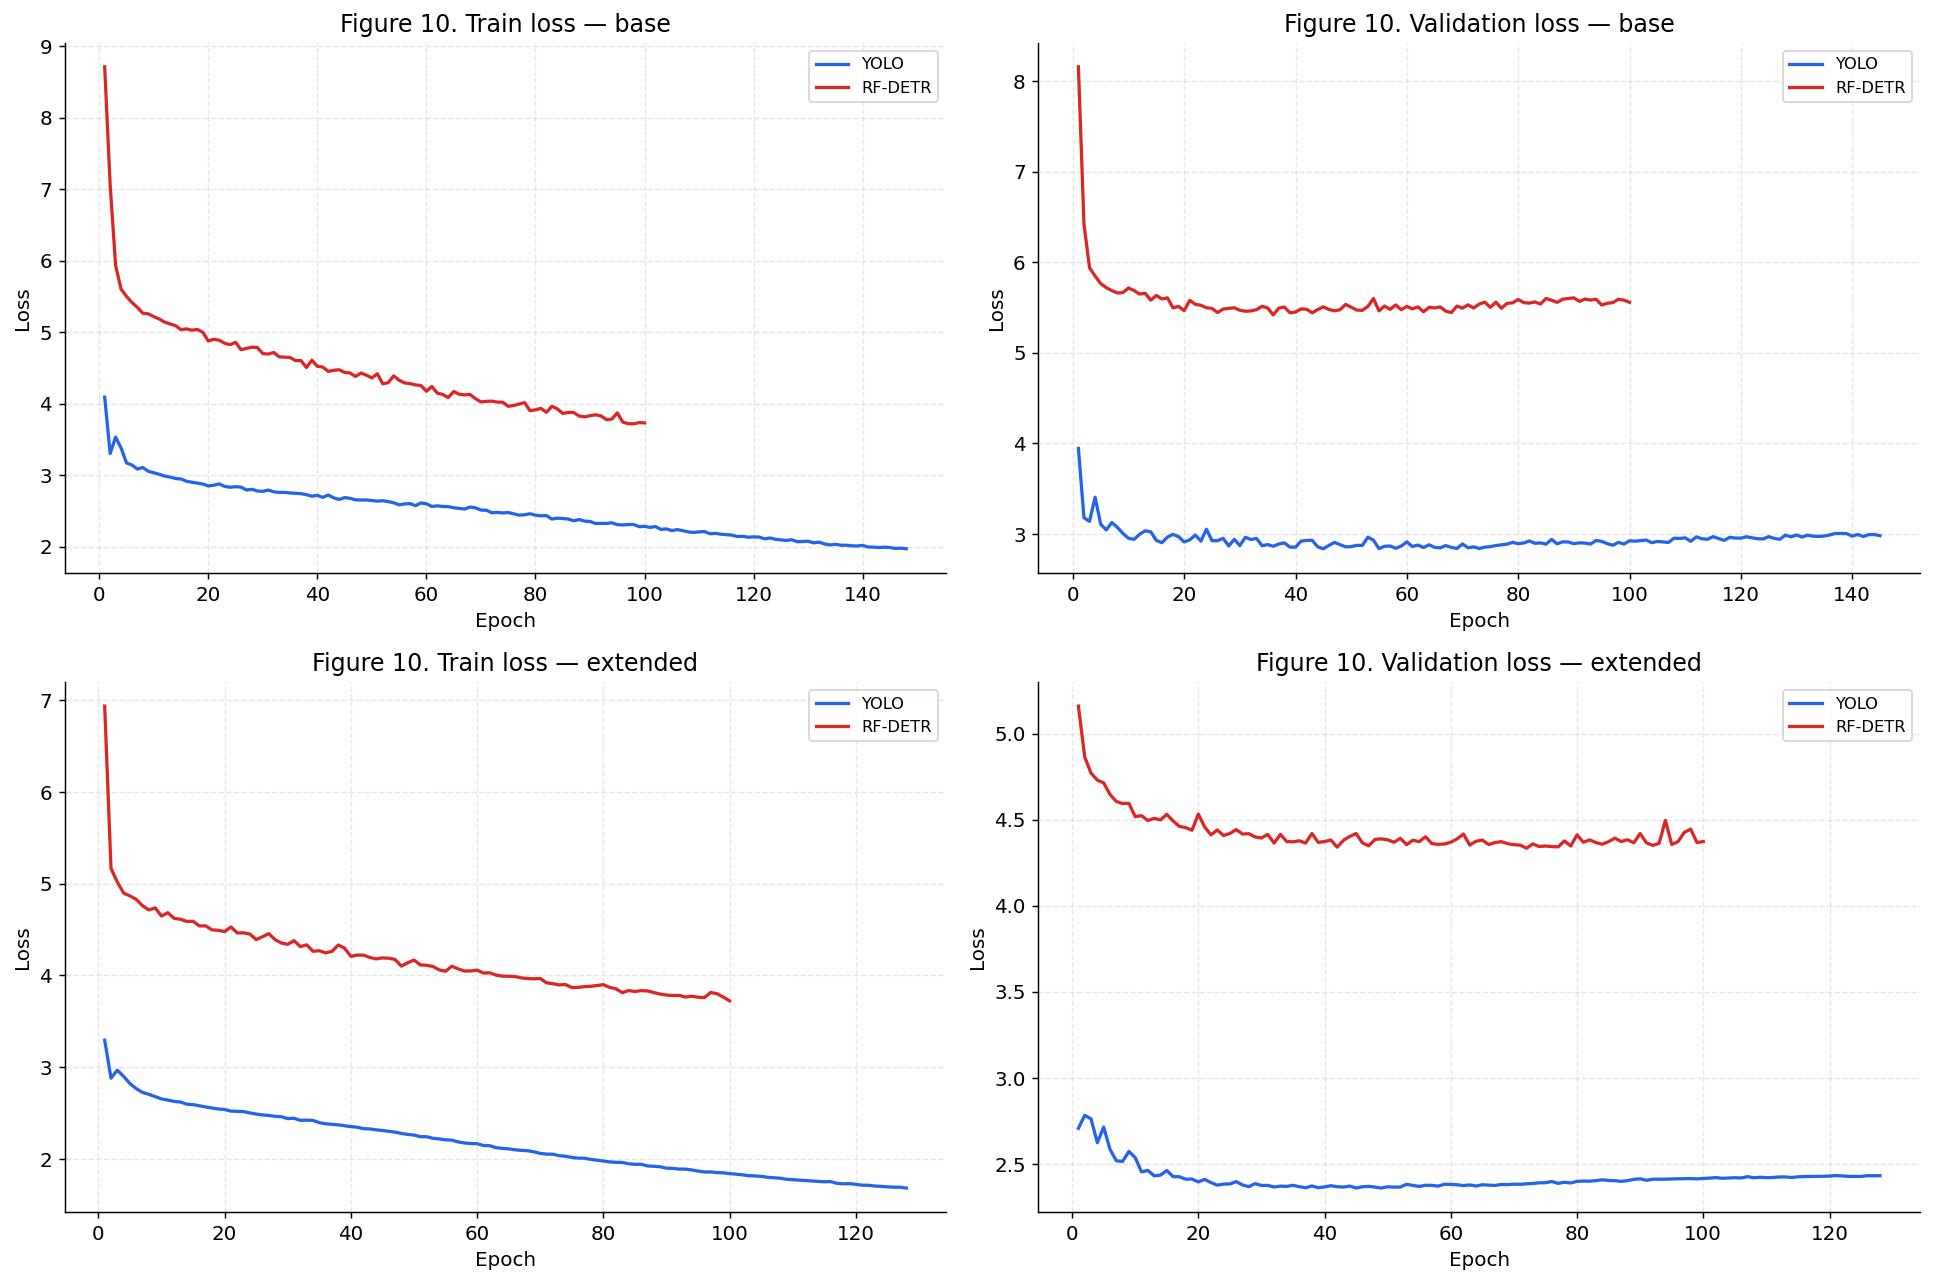

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for (ax_train, ax_val), var in zip(
    [(axes[0][0], axes[0][1]), (axes[1][0], axes[1][1])],
    ["base", "extended"],
):
    for model_key, color, label in [
        ("yolo",   YOLO_COLOR,   "YOLO"),
        ("rfdetr", RFDETR_COLOR, "RF-DETR"),
    ]:
        match = [v for v in runs_data.values()
                 if v["model"] == model_key and v["dataset_variant"] == var]
        if not match:
            continue
        d = match[0]
        tl = np.array(d["loss_history"])
        vl = np.array(d["val_loss_clean"])
        ep_t = np.arange(1, len(tl) + 1)
        ep_v = np.arange(1, len(vl) + 1)
        ax_train.plot(ep_t, tl, color=color, linewidth=1.8, label=label)
        ax_val.plot(ep_v, vl, color=color, linewidth=1.8, label=label)

    for ax, split_name in [(ax_train, "Train"), (ax_val, "Validation")]:
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title(f"Figure 10. {split_name} loss — {var}")
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Loss trends:**

- **YOLO train loss** decreases smoothly and steadily throughout training on all variants, which is a sign of stable optimisation with AMP enabled.
- **RF-DETR train loss** drops sharply in the first 20 epochs then stalls, consistent with a model that saturates its capacity on the training set quickly.
- **Validation losses** diverge between the two models: YOLO's val loss continues to decrease alongside training loss, while RF-DETR's val loss stays relatively flat or rises slightly after the initial drop. That is the signature of early-epoch overfitting on smaller variants.

## 7. Qualitative Examples

The cell below loads and displays saved prediction frames from `outputs/predictions/`.

In [ ]:
from pathlib import Path

try:
    from PIL import Image
    PIL_AVAILABLE = True
except ImportError:
    PIL_AVAILABLE = False

PRED_ROOT = Path("../outputs/predictions/preview")

def show_prediction_grid(run_names: list, max_per_run: int = 3):
    """Display saved prediction frames for a list of runs."""
    if not PIL_AVAILABLE:
        print("Pillow not available — install with: pip install Pillow")
        return

    collected = {}
    for run in run_names:
        run_dir = PRED_ROOT / run
        if not run_dir.exists():
            collected[run] = []
            continue
        imgs = sorted(run_dir.glob("*.jpg"))[:max_per_run]
        if not imgs:
            imgs = sorted(run_dir.glob("*.png"))[:max_per_run]
        collected[run] = imgs

    if not any(collected.values()):
        print(
            "No prediction images found in outputs/predictions/.\n"
            "Run scripts/predict.py to generate them, then re-run this cell."
        )
        return

    n_rows = len(run_names)
    n_cols = max_per_run
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    if n_rows == 1:
        axes = [axes]

    for row_axes, run in zip(axes, run_names):
        if n_cols == 1:
            row_axes = [row_axes]
        imgs = collected.get(run, [])
        for ax, img_path in zip(row_axes, imgs):
            ax.imshow(Image.open(img_path))
            ax.set_title(f"{run}\n{img_path.stem}", fontsize=8)
            ax.axis("off")
        for ax in row_axes[len(imgs):]:
            ax.axis("off")

    plt.suptitle("Figure 11. Sample prediction frames (bounding boxes overlaid)", fontsize=12)
    plt.tight_layout()
    plt.show()

show_prediction_grid([
    "yolo-base-full-v2",
    "rfdetr-base-full-v2",
    "yolo-extended-full-v2",
    "rfdetr-extended-full-v2",
])

No prediction images found in outputs/predictions/.
Run scripts/predict.py to generate them, then re-run this cell.


## 8. Summary Dashboard

A single-figure overview of all key metrics across all eight runs.

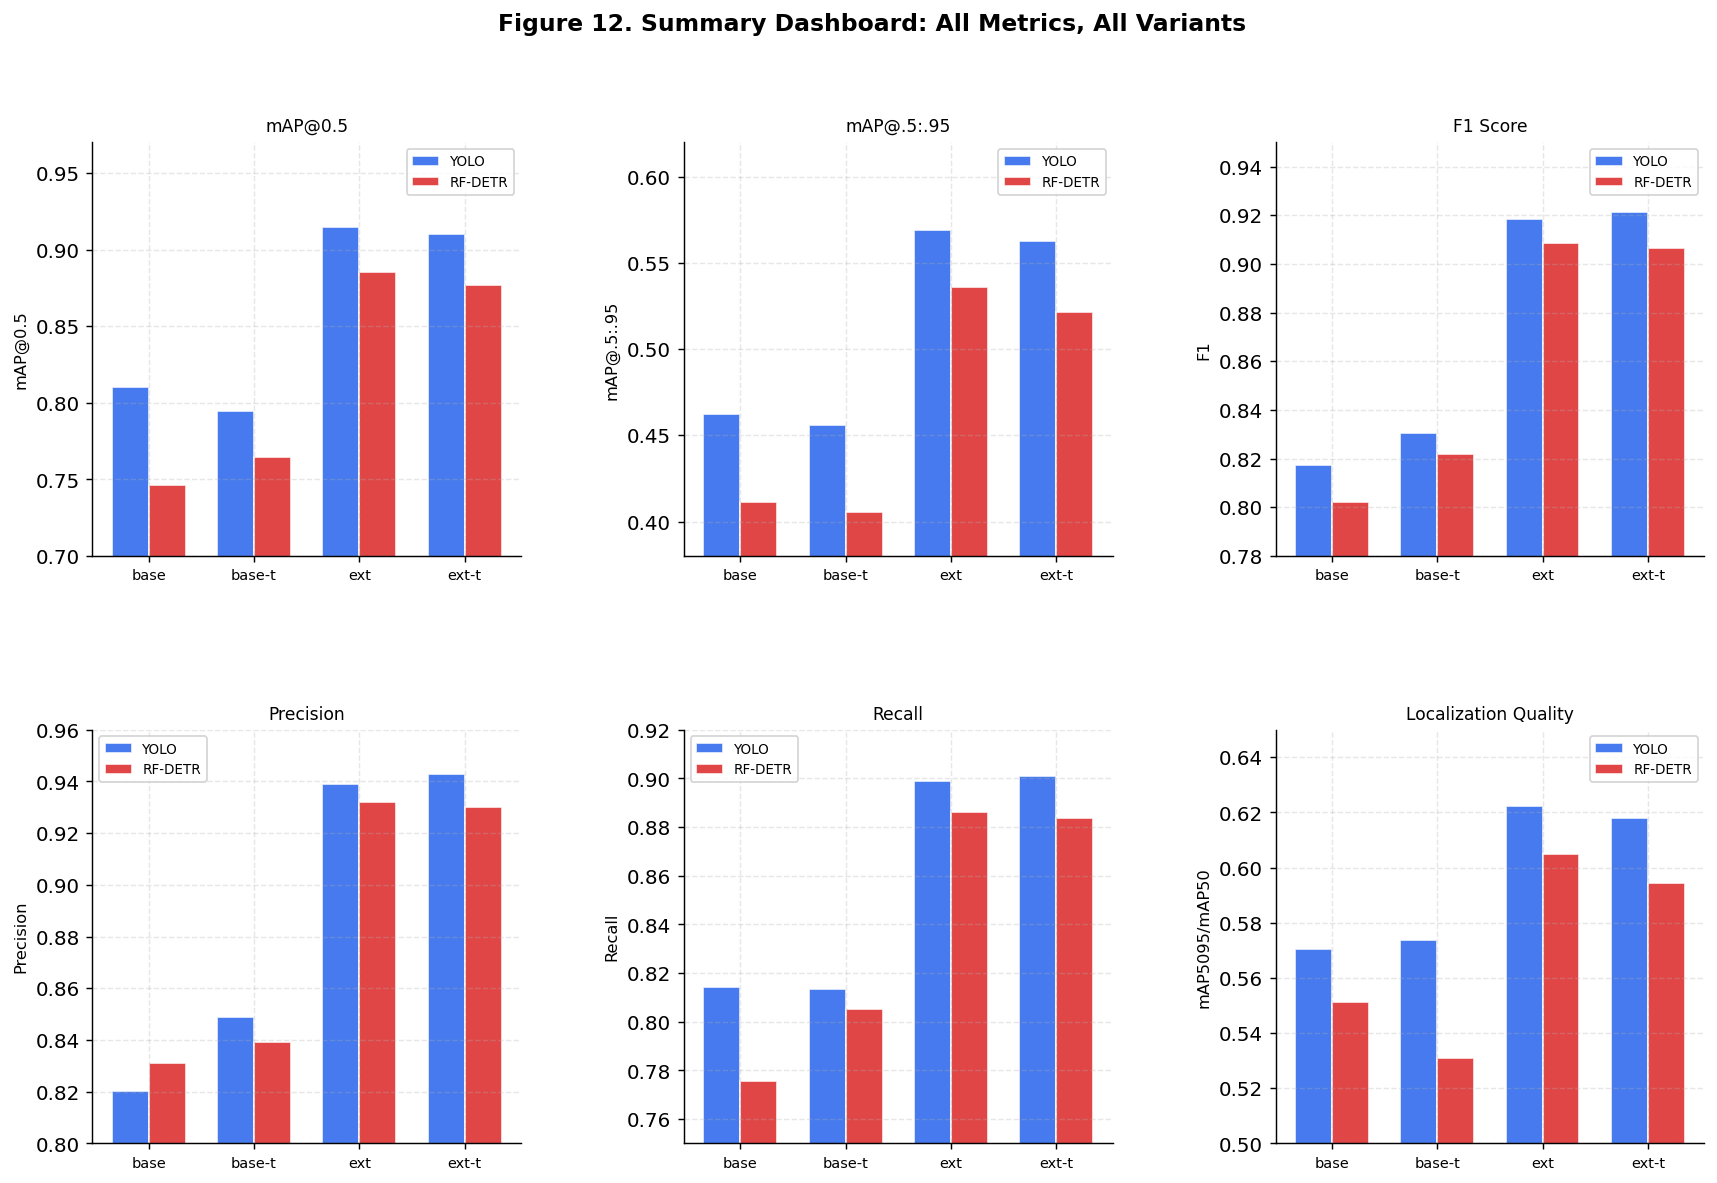

In [18]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

x = np.arange(len(VARIANT_ORDER))
w = 0.35

def grouped_bars(ax, metric_key, ylabel, title, ylim=None):
    for i, (mk, color, lbl) in enumerate([("yolo",YOLO_COLOR,"YOLO"),("rfdetr",RFDETR_COLOR,"RF-DETR")]):
        vals = []
        for var in VARIANT_ORDER:
            m = [v for v in runs_data.values() if v["model"]==mk and v["dataset_variant"]==var]
            vals.append(m[0][metric_key] if m else 0)
        ax.bar(x+i*w, vals, w, label=lbl, color=color, alpha=0.85, edgecolor="white")
    ax.set_xticks(x+w/2)
    ax.set_xticklabels(["base","base-t","ext","ext-t"], fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=9.5)
    if ylim: ax.set_ylim(*ylim)
    ax.legend(fontsize=7.5)

grouped_bars(ax1, "mAP50",    "mAP@0.5",      "mAP@0.5",    (0.70, 0.97))
grouped_bars(ax2, "mAP5095",  "mAP@.5:.95",   "mAP@.5:.95", (0.38, 0.62))
grouped_bars(ax3, "f1",       "F1",            "F1 Score",   (0.78, 0.95))
grouped_bars(ax4, "precision","Precision",     "Precision",  (0.80, 0.96))
grouped_bars(ax5, "recall",   "Recall",        "Recall",     (0.75, 0.92))
grouped_bars(ax6, "loc_quality","mAP5095/mAP50","Localization Quality", (0.50, 0.65))

fig.suptitle("Figure 12. Summary Dashboard: All Metrics, All Variants", fontsize=13, fontweight="bold")
plt.show()

## 9. Conclusions

### 9.1 Best runs - head to head

In [19]:
best_rows = []
for model_key in ["yolo", "rfdetr"]:
    group = [v for v in runs_data.values() if v["model"] == model_key]
    best  = max(group, key=lambda x: x["mAP50"])
    best_rows.append({
        "Model":             model_key.upper(),
        "Best run":          best["run_name"],
        "Dataset variant":   best["dataset_variant"],
        "Epochs run":        best["epochs_run"],
        "Best epoch":        best["best_epoch"],
        "mAP@0.5":           best["mAP50"],
        "mAP@.5:.95":        best["mAP5095"],
        "F1":                best["f1"],
        "Precision":         best["precision"],
        "Recall":            best["recall"],
        "Loc. quality":      best["loc_quality"],
        "Stability (σ)":     best["stability"],
        "Gen. gap":          best["gen_gap"],
    })

df_best = pd.DataFrame(best_rows)
display(df_best.T.style
    .set_caption("Table 6. Best run per model — final comparison.")
    .format(lambda x: f"{x:.4f}" if isinstance(x, float) else x))

,0,1
Model,YOLO,RFDETR
Best run,yolo-extended-full-v2,rfdetr-extended-full-v2
Dataset variant,extended,extended
Epochs run,128,100
Best epoch,113,27
mAP@0.5,0.9144,0.8856
mAP@.5:.95,0.5692,0.5358
F1,0.9185,0.9085
Precision,0.9391,0.9321
Recall,0.8989,0.8861


### 9.2 Answers to the research questions

**Q1. Which model achieves better detection quality?**

**YOLO wins across all four dataset variants.** On `extended` (the largest, most realistic variant), YOLO reaches mAP@0.5 = 0.914, F1 = 0.919, and mAP@.5:.95 = 0.569, compared to RF-DETR's 0.886, 0.909, and 0.536 respectively. The gap is consistent and widest on small data (`base`: +6.4 pp mAP@0.5) and smallest on large data (`extended`: +2.9 pp). YOLO also produces higher-quality bounding boxes (better localization ratio) across all variants.

---

**Q2. How does the choice of training data affect each model?**

Both models gain substantially from the `extended` variant (+10–14 pp mAP@0.5). **RF-DETR is more data-responsive**. It gains +14 pp vs YOLO's +10 pp, suggesting a larger model capacity that is underutilised on small datasets. Transforms have a **near-neutral effect** for both architectures: YOLO has its own built-in online augmentations (mosaic, flip, HSV), making external transforms largely redundant; RF-DETR shows only marginal and inconsistent changes from transforms. The single most impactful decision for both models is adding the extended ball dataset, not adding transforms.

---

**Q3. How do training dynamics differ?**

This is where the architectures diverge most clearly:

| Aspect | YOLO | RF-DETR |
|--------|------|---------|
| Convergence pattern | Gradual, steady improvement | Fast initial rise, early plateau |
| Best epoch (base) | ~110/148 | ~24/100 |
| Post-peak wasted epochs | ~38 | ~76 |
| Stability (late training) | High | Moderate (oscillates on small data) |
| Generalization gap | Moderate, decreasing with data | High on small data, drops with `extended` |
| Overfitting signal | Mild | Noticeable on `base` variants |


---

**Q4. Which model is more practical?**

**YOLO is significantly more practical** for this project. It requires one adapter module vs four for RF-DETR, has automatic early stopping, built-in AMP, cleaner logs, and faster inference. The RF-DETR adapter required substantial extra engineering to suppress backend logs, handle checkpoint selection, and wrap the inference API. Both models integrate transparently into the shared analysis pipeline, but the operational burden of RF-DETR is notably higher.

---

### 9.3 Recommendation

For the production pipeline of the Murawa project, **`yolo-extended-full-v2`** is the recommended default model. It achieves the highest mAP@0.5 (0.914), best localization quality, and the most stable late-training behaviour, within the simplest integration footprint.

RF-DETR (`rfdetr-extended-full-v2`, mAP@0.5 = 0.886) remains a valid reference point and should be revisited if the training dataset grows substantially — its stronger data-scaling response suggests it may close the gap or overtake YOLO at larger scales.

---